In [1]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras import backend as K


In [4]:

from tensorflow.keras.datasets import cifar10

# Load the CIFAR-10 dataset
(xtrain, ytrain), (xtest, ytest) = cifar10.load_data()

# Normalize pixel values (0-255 → 0-1)
xtrain = xtrain / 255.0
xtest = xtest / 255.0

# Display the shape of the training data
print(xtrain.shape)


(50000, 32, 32, 3)


In [3]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(512, activation="relu"),

    Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



In [6]:
loss, accuracy = model.evaluate(xtest, ytest)

print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1152 - loss: 2.3048
Loss: 2.304797410964966
Accuracy: 0.1151999980211258


In [7]:

import tensorflow as tf
from tensorflow.keras import  layers,models
import matplotlib.pyplot as plt

In [8]:
xtrain=xtrain/255.0
xtest=xtest/255.0


In [9]:
class_names=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]


In [10]:
model=models.Sequential()
model.add(layers.Conv2D(32,(3,3),
activation="relu",input_shape=(32,32,3)))
model.add(layers. MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(64,activation="relu"))
model.add(layers.Dense(10,activation="softmax"))

In [11]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=['accuracy'])


In [12]:
f = model.fit(xtrain, ytrain, epochs=15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.2282 - loss: 2.1047
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3144 - loss: 1.9188
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3455 - loss: 1.8391
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3681 - loss: 1.7713
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3910 - loss: 1.7122
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4072 - loss: 1.6685
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4195 - loss: 1.6327
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4283 - loss: 1.6046
Epoch 9/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4379 - loss: 1.5804
Epoch 10/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4476 - loss: 1.5619
Epoch 11/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4515 - loss: 1.5408
Epoch 12/15
1563/1563 ━━━━━━━━

In [13]:
p=model.predict(xtest)
p

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[0.00823132, 0.01814002, 0.02326887, ..., 0.00241197, 0.12429396,
        0.0063114 ],
       [0.09457619, 0.29199958, 0.00483259, ..., 0.00134454, 0.32053795,
        0.28034338],
       [0.09205487, 0.1567076 , 0.0047185 , ..., 0.00114877, 0.5582438 ,
        0.17961241],
       ...,
       [0.00165762, 0.0007359 , 0.08328675, ..., 0.05909339, 0.00251013,
        0.00286495],
       [0.15694456, 0.05688953, 0.20005488, ..., 0.09422082, 0.03295727,
        0.05242469],
       [0.0071047 , 0.00096537, 0.09809643, ..., 0.46919075, 0.00078433,
        0.00497194]], dtype=float32)

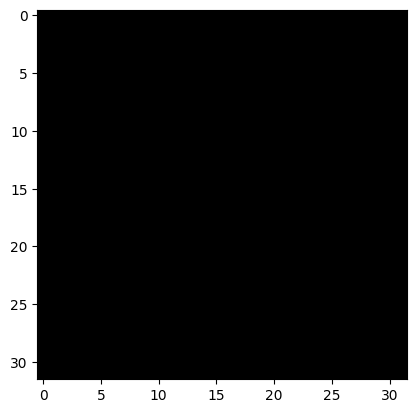

In [14]:

import numpy as np
index = 5
plt.imshow(xtest[index])
class_names[np.argmax(p[index])]
plt.show()

In [15]:
from tensorflow.keras.preprocessing import image

In [17]:
img=image.load_img("/content/images 3.jpg",target_size=(32,32))
img_arr=image.img_to_array(img)/255.0
img_arr=tf.expand_dims(img_arr,axis=0)
p=model.predict(img_arr)
print(class_names[np.argmax(p)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
automobile


array([[[ 37, 158, 177],
        [ 38, 159, 178],
        [ 39, 160, 179],
        ...,
        [230, 230, 220],
        [240, 240, 230],
        [245, 245, 235]],

       [[ 41, 160, 180],
        [ 41, 160, 180],
        [ 42, 161, 181],
        ...,
        [224, 224, 214],
        [234, 234, 224],
        [240, 240, 230]],

       [[ 48, 163, 182],
        [ 48, 163, 182],
        [ 49, 164, 183],
        ...,
        [226, 226, 216],
        [236, 236, 226],
        [242, 242, 232]],

       ...,

       [[ 36,  22,  11],
        [ 46,  29,  19],
        [ 57,  37,  30],
        ...,
        [112,  57,  27],
        [116,  61,  31],
        [117,  62,  32]],

       [[ 33,  23,  11],
        [ 43,  31,  19],
        [ 57,  37,  30],
        ...,
        [112,  57,  27],
        [116,  61,  31],
        [117,  62,  32]],

       [[ 33,  23,  11],
        [ 43,  31,  19],
        [ 57,  37,  30],
        ...,
        [112,  57,  27],
        [115,  60,  30],
        [117,  62,  32]]], dtype=uint8)
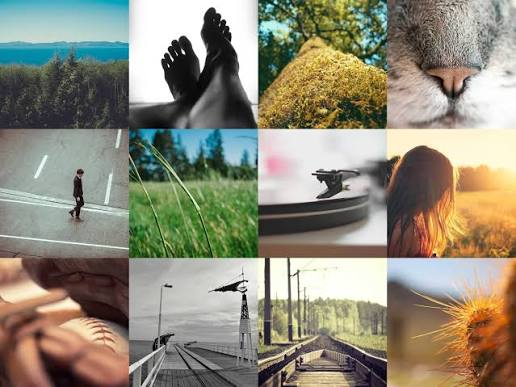

In [18]:
from PIL import Image
import numpy as np
a=Image.open("/content/images 3.jpg")
image=np.array(a)
image